In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RESULTS_DIR = Path("results")

# Load all final outputs

In [2]:
DEMAND_RESULTS_PATH = (
    RESULTS_DIR /
    "semisynthetic_demand_model_results_v1.csv"
)

UPLIFT_PATH = (
    RESULTS_DIR /
    "promotion_uplift_tlearner_v1.parquet"
)

OPTIMIZED_PATH = (
    RESULTS_DIR /
    "profit_optimized_promotions_v2.parquet"
)

STRATEGY_PATH = (
    RESULTS_DIR /
    "promotion_strategy_comparison_v2.csv"
)

demand_results = pd.read_csv(
    DEMAND_RESULTS_PATH
)

uplift = pd.read_parquet(
    UPLIFT_PATH
)

optimized = pd.read_parquet(
    OPTIMIZED_PATH
)

strategy = pd.read_csv(
    STRATEGY_PATH
)

uplift["week_start"] = pd.to_datetime(
    uplift["week_start"]
)

optimized["week_start"] = pd.to_datetime(
    optimized["week_start"]
)

# Final data QA

In [3]:
print("=== FINAL DATA QA ===")

print(
    "Uplift rows:",
    len(uplift)
)

print(
    "Optimized rows:",
    len(optimized)
)

print(
    "Stores:",
    optimized["store_id"].nunique()
)

print(
    "Products:",
    uplift["product_id"].nunique()
)

print(
    "Test weeks:",
    uplift["week_start"].nunique()
)

print(
    "Date range:",
    uplift["week_start"].min(),
    "→",
    uplift["week_start"].max()
)

print(
    "Duplicate store/product/week:",
    uplift.duplicated(
        subset=[
            "week_start",
            "store_id",
            "product_id"
        ]
    ).sum()
)

=== FINAL DATA QA ===
Uplift rows: 54000
Optimized rows: 3600
Stores: 15
Products: 300
Test weeks: 12
Date range: 2026-06-22 00:00:00 → 2026-09-07 00:00:00
Duplicate store/product/week: 0


# Part A — Demand model

# Demand forecasting results

In [4]:
display(
    demand_results
)

,split,model,MAE,RMSE,WMAPE_pct
0,validation,Lag-1 Baseline,4.356741,5.677415,31.783713
1,validation,CatBoost,3.062484,3.900203,22.341727
2,test,CatBoost,3.090026,3.943933,21.900207


# Calculate improvement over baseline

In [5]:
baseline_row = demand_results[
    (
        demand_results["split"]
        == "validation"
    )
    &
    (
        demand_results["model"]
        == "Lag-1 Baseline"
    )
].iloc[0]

catboost_val = demand_results[
    (
        demand_results["split"]
        == "validation"
    )
    &
    (
        demand_results["model"]
        == "CatBoost"
    )
].iloc[0]

mae_improvement = (
    (
        baseline_row["MAE"]
        - catboost_val["MAE"]
    )
    / baseline_row["MAE"]
    * 100
)

wmape_improvement = (
    (
        baseline_row["WMAPE_pct"]
        - catboost_val["WMAPE_pct"]
    )
    / baseline_row["WMAPE_pct"]
    * 100
)

print(
    "MAE improvement vs Lag-1:",
    round(mae_improvement, 2),
    "%"
)

print(
    "WMAPE improvement vs Lag-1:",
    round(wmape_improvement, 2),
    "%"
)

MAE improvement vs Lag-1: 29.71 %
WMAPE improvement vs Lag-1: 29.71 %


# Uplift model

# Calculate final uplift metrics

In [6]:
true_uplift = (
    uplift[
        "true_incremental_units"
    ].to_numpy()
)

pred_uplift = (
    uplift[
        "predicted_uplift_units"
    ].to_numpy()
)

uplift_mae = np.mean(
    np.abs(
        true_uplift
        - pred_uplift
    )
)

uplift_rmse = np.sqrt(
    np.mean(
        (
            true_uplift
            - pred_uplift
        ) ** 2
    )
)

uplift_corr = np.corrcoef(
    true_uplift,
    pred_uplift
)[0, 1]

print(
    "Uplift MAE:",
    round(uplift_mae, 3)
)

print(
    "Uplift RMSE:",
    round(uplift_rmse, 3)
)

print(
    "Uplift correlation:",
    round(uplift_corr, 3)
)

print(
    "True mean uplift:",
    round(
        true_uplift.mean(),
        3
    )
)

print(
    "Predicted mean uplift:",
    round(
        pred_uplift.mean(),
        3
    )
)

Uplift MAE: 0.957
Uplift RMSE: 1.345
Uplift correlation: 0.828
True mean uplift: 3.08
Predicted mean uplift: 2.365


# Uplift ranking quality

In [7]:
ranked = (
    uplift
    .sort_values(
        "predicted_uplift_units",
        ascending=False
    )
    .reset_index(drop=True)
)

uplift_k_results = []

for pct in [
    0.10,
    0.20,
    0.30
]:

    n = int(
        len(ranked)
        * pct
    )

    value = (
        ranked
        .head(n)[
            "true_incremental_units"
        ]
        .mean()
    )

    uplift_k_results.append({
        "top_pct":
            int(pct * 100),

        "true_avg_uplift":
            value
    })

uplift_k = pd.DataFrame(
    uplift_k_results
)

display(uplift_k)

,top_pct,true_avg_uplift
0,10,6.672401
1,20,5.743387
2,30,5.198051


# Compare top recommendations vs average

In [8]:
overall_true_uplift = (
    uplift[
        "true_incremental_units"
    ].mean()
)

top10_true_uplift = (
    uplift_k.loc[
        uplift_k["top_pct"] == 10,
        "true_avg_uplift"
    ]
    .iloc[0]
)

uplift_enrichment = (
    top10_true_uplift
    / overall_true_uplift
)

print(
    "Overall true uplift:",
    round(
        overall_true_uplift,
        3
    )
)

print(
    "Top 10% true uplift:",
    round(
        top10_true_uplift,
        3
    )
)

print(
    "Top-10% enrichment:",
    round(
        uplift_enrichment,
        2
    ),
    "x"
)

Overall true uplift: 3.08
Top 10% true uplift: 6.672
Top-10% enrichment: 2.17 x


# Profit optimization

# Strategy comparison

In [9]:
display(
    strategy.sort_values(
        "true_incremental_profit",
        ascending=False
    )
)

,strategy,selected_products,predicted_incremental_profit,true_incremental_profit,avg_true_profit_per_selection,positive_profit_rate_pct
3,Oracle,3600,15968.325853,26451.582075,7.347662,100.000000
2,Profit Optimizer,3600,22296.018504,20615.427117,5.726508,97.055556
1,Highest Predicted Uplift,3242,-10961.227337,-10097.664296,-3.114640,38.741518
0,Largest Discount,3312,-21846.524949,-16619.311787,-5.017908,26.751208


# Extract optimizer performance

In [10]:
optimizer_row = (
    strategy[
        strategy["strategy"]
        == "Profit Optimizer"
    ]
    .iloc[0]
)

oracle_row = (
    strategy[
        strategy["strategy"]
        == "Oracle"
    ]
    .iloc[0]
)

discount_row = (
    strategy[
        strategy["strategy"]
        == "Largest Discount"
    ]
    .iloc[0]
)

uplift_row = (
    strategy[
        strategy["strategy"]
        == "Highest Predicted Uplift"
    ]
    .iloc[0]
)

# Oracle regret

In [11]:
optimizer_profit = (
    optimizer_row[
        "true_incremental_profit"
    ]
)

oracle_profit = (
    oracle_row[
        "true_incremental_profit"
    ]
)

oracle_regret_pct = (
    (
        oracle_profit
        - optimizer_profit
    )
    / oracle_profit
    * 100
)

print(
    "Optimizer true profit:",
    round(
        optimizer_profit,
        2
    )
)

print(
    "Oracle true profit:",
    round(
        oracle_profit,
        2
    )
)

print(
    "Oracle regret:",
    round(
        oracle_regret_pct,
        2
    ),
    "%"
)

Optimizer true profit: 20615.43
Oracle true profit: 26451.58
Oracle regret: 22.06 %


# Compare against naive discounting

In [12]:
discount_profit = (
    discount_row[
        "true_incremental_profit"
    ]
)

absolute_gain_vs_discount = (
    optimizer_profit
    - discount_profit
)

print(
    "Largest-discount profit:",
    round(
        discount_profit,
        2
    )
)

print(
    "Profit optimizer:",
    round(
        optimizer_profit,
        2
    )
)

print(
    "Absolute gain vs discount:",
    round(
        absolute_gain_vs_discount,
        2
    )
)

Largest-discount profit: -16619.31
Profit optimizer: 20615.43
Absolute gain vs discount: 37234.74


# Compare uplift-only strategy

In [13]:
uplift_only_profit = (
    uplift_row[
        "true_incremental_profit"
    ]
)

print(
    "Highest-uplift strategy:",
    round(
        uplift_only_profit,
        2
    )
)

print(
    "Profit-aware strategy:",
    round(
        optimizer_profit,
        2
    )
)

Highest-uplift strategy: -10097.66
Profit-aware strategy: 20615.43


# Constraints

# Validate business constraints

In [14]:
store_week_qa = (
    optimized
    .groupby(
        [
            "week_start",
            "store_id"
        ]
    )
    .agg(
        flyer_slots=(
            "product_id",
            "count"
        ),

        promo_spend=(
            "promo_spend_proxy",
            "sum"
        )
    )
    .reset_index()
)

category_qa = (
    optimized
    .groupby(
        [
            "week_start",
            "store_id",
            "category"
        ]
    )
    .size()
)

print(
    "Maximum flyer slots:",
    store_week_qa[
        "flyer_slots"
    ].max()
)

print(
    "Maximum promotion spend:",
    round(
        store_week_qa[
            "promo_spend"
        ].max(),
        2
    )
)

print(
    "Maximum products/category:",
    category_qa.max()
)

Maximum flyer slots: 20
Maximum promotion spend: 298.02
Maximum products/category: 4


# Store personalization

# Performance by store

In [15]:
store_results = (
    optimized
    .groupby(
        [
            "store_id",
            "store_name"
        ]
    )
    .agg(
        selected_promotions=(
            "product_id",
            "count"
        ),

        predicted_incremental_profit=(
            "pred_incremental_profit",
            "sum"
        ),

        true_incremental_profit=(
            "true_incremental_profit_eval",
            "sum"
        ),

        avg_predicted_uplift=(
            "predicted_uplift_units",
            "mean"
        )
    )
    .reset_index()
)

display(
    store_results.sort_values(
        "true_incremental_profit",
        ascending=False
    )
)

,store_id,store_name,selected_promotions,predicted_incremental_profit,true_incremental_profit,avg_predicted_uplift
11,3106,Toronto Dufferin Mall,240,2831.184353,2209.020247,6.294057
5,1150,Toronto Downtown East,240,2192.183412,1952.678830,4.766453
0,1004,Toronto Stockyards,240,1797.093553,1568.920999,4.154585
3,1126,Mississauga East,240,1422.608103,1480.371861,3.319028
10,3105,Toronto North Park,240,1747.451310,1464.963901,4.104111
9,3055,Mississauga Square One,240,1393.305819,1411.579083,3.180867
12,3130,Brampton North,240,1362.543609,1319.851580,3.013241
6,1188,Brampton South,240,1232.486259,1253.588268,2.858684
1,1061,Mississauga Heartland,240,1255.134237,1233.566278,2.988864
4,1139,Toronto Downsview,240,1385.887030,1211.717120,3.201895


# Performance by category

In [16]:
category_results = (
    optimized
    .groupby("category")
    .agg(
        selected_count=(
            "product_id",
            "count"
        ),

        avg_predicted_uplift=(
            "predicted_uplift_units",
            "mean"
        ),

        predicted_profit=(
            "pred_incremental_profit",
            "sum"
        ),

        true_profit=(
            "true_incremental_profit_eval",
            "sum"
        )
    )
    .reset_index()
)

display(
    category_results.sort_values(
        "true_profit",
        ascending=False
    )
)

,category,selected_count,avg_predicted_uplift,predicted_profit,true_profit
5,Hot Beverages,616,3.199040,4747.068527,4319.784730
2,Cold Beverages,511,4.048495,3338.861152,3856.916271
9,Snacks,588,4.239088,3769.592776,3276.299471
8,Ready-to-Eat,590,3.390249,3769.215113,2814.112004
7,Personal Care,379,1.597352,1865.458569,1906.139185
4,Frozen Food,284,3.023851,1434.661017,1716.810669
0,Breakfast,243,3.917399,1405.155049,1557.702493
1,Cleaning,161,3.460826,776.224650,681.676928
6,Household Staples,170,4.120853,937.132015,323.251489
3,Dairy,58,2.929823,252.649636,162.733876


# Simple visualizations

# Strategy profit chart

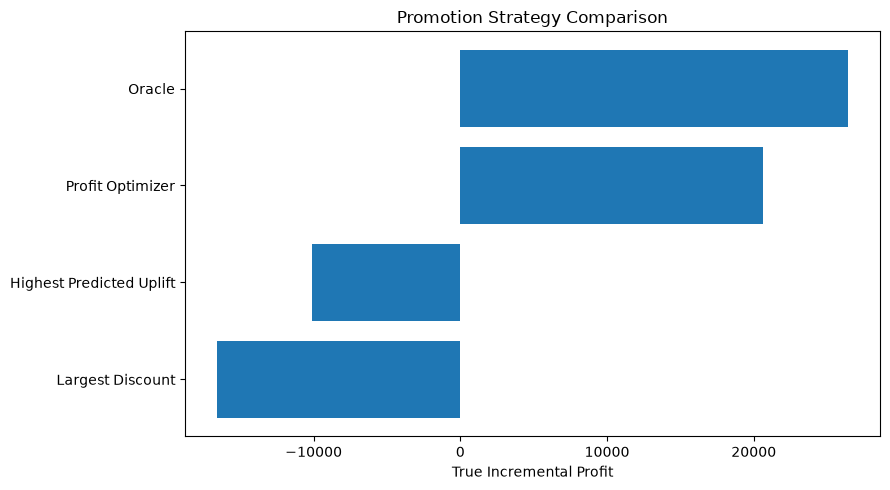

In [17]:
plot_data = (
    strategy
    .sort_values(
        "true_incremental_profit"
    )
)

plt.figure(
    figsize=(9, 5)
)

plt.barh(
    plot_data["strategy"],
    plot_data[
        "true_incremental_profit"
    ]
)

plt.xlabel(
    "True Incremental Profit"
)

plt.title(
    "Promotion Strategy Comparison"
)

plt.tight_layout()
plt.show()

# Predicted vs true uplift

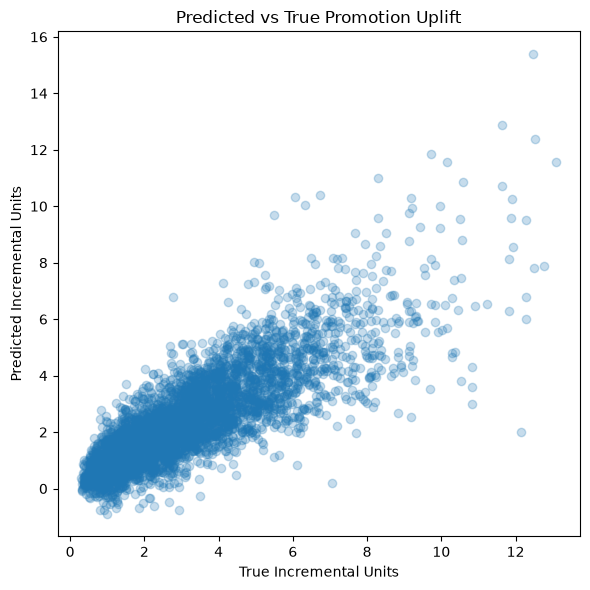

In [18]:
sample = uplift.sample(
    min(
        5000,
        len(uplift)
    ),
    random_state=42
)

plt.figure(
    figsize=(6, 6)
)

plt.scatter(
    sample[
        "true_incremental_units"
    ],
    sample[
        "predicted_uplift_units"
    ],
    alpha=0.25
)

plt.xlabel(
    "True Incremental Units"
)

plt.ylabel(
    "Predicted Incremental Units"
)

plt.title(
    "Predicted vs True Promotion Uplift"
)

plt.tight_layout()
plt.show()

# Final system metrics

# Create one final metrics table

In [19]:
test_catboost = (
    demand_results[
        (
            demand_results["split"]
            == "test"
        )
        &
        (
            demand_results["model"]
            == "CatBoost"
        )
    ]
    .iloc[0]
)

final_metrics = pd.DataFrame({
    "metric": [
        "Demand test MAE",
        "Demand test RMSE",
        "Demand test WMAPE %",
        "Uplift MAE",
        "Uplift RMSE",
        "Uplift correlation",
        "Overall true uplift",
        "Top 10% true uplift",
        "Top 10% uplift enrichment",
        "Optimizer true incremental profit",
        "Oracle true incremental profit",
        "Oracle regret %",
        "Largest-discount true profit",
        "Positive-profit optimizer selections %"
    ],

    "value": [
        test_catboost["MAE"],
        test_catboost["RMSE"],
        test_catboost["WMAPE_pct"],

        uplift_mae,
        uplift_rmse,
        uplift_corr,

        overall_true_uplift,
        top10_true_uplift,
        uplift_enrichment,

        optimizer_profit,
        oracle_profit,
        oracle_regret_pct,

        discount_profit,

        optimizer_row[
            "positive_profit_rate_pct"
        ]
    ]
})

display(final_metrics)

,metric,value
0,Demand test MAE,3.090026
1,Demand test RMSE,3.943933
2,Demand test WMAPE %,21.900207
3,Uplift MAE,0.956793
4,Uplift RMSE,1.345196
5,Uplift correlation,0.828306
6,Overall true uplift,3.080211
7,Top 10% true uplift,6.672401
8,Top 10% uplift enrichment,2.166216
9,Optimizer true incremental profit,20615.427117


# Save everything

In [20]:
FINAL_METRICS_PATH = (
    RESULTS_DIR /
    "final_long_version_metrics.csv"
)

STORE_RESULTS_PATH = (
    RESULTS_DIR /
    "final_store_results.csv"
)

CATEGORY_RESULTS_PATH = (
    RESULTS_DIR /
    "final_category_results.csv"
)

final_metrics.to_csv(
    FINAL_METRICS_PATH,
    index=False
)

store_results.to_csv(
    STORE_RESULTS_PATH,
    index=False
)

category_results.to_csv(
    CATEGORY_RESULTS_PATH,
    index=False
)

print(
    "Saved:",
    FINAL_METRICS_PATH
)

print(
    "Saved:",
    STORE_RESULTS_PATH
)

print(
    "Saved:",
    CATEGORY_RESULTS_PATH
)

Saved: results/final_long_version_metrics.csv
Saved: results/final_store_results.csv
Saved: results/final_category_results.csv


# Final project summary

In [21]:
print(
    """
=== LONG VERSION COMPLETE ===

1. Real GTA store context:
   StatsCan + OpenStreetMap

2. Real historical weather

3. Semi-synthetic:
   300 products
   promotion history
   sales outcomes
   margins
   inventory
   true treatment effects

4. Demand prediction:
   CatBoost

5. Promotion effect:
   T-Learner

6. Business decision:
   predicted incremental profit

7. Optimization:
   flyer slots
   category diversity
   promotion budget
   inventory

8. Evaluation:
   baseline
   uplift ranking
   naive discounting
   profit optimizer
   oracle benchmark
"""
)


=== LONG VERSION COMPLETE ===

1. Real GTA store context:
   StatsCan + OpenStreetMap

2. Real historical weather

3. Semi-synthetic:
   300 products
   promotion history
   sales outcomes
   margins
   inventory
   true treatment effects

4. Demand prediction:
   CatBoost

5. Promotion effect:
   T-Learner

6. Business decision:
   predicted incremental profit

7. Optimization:
   flyer slots
   category diversity
   promotion budget
   inventory

8. Evaluation:
   baseline
   uplift ranking
   naive discounting
   profit optimizer
   oracle benchmark

